In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suvidyasonawane/house-price-prediction-dataset")

print("Path to dataset files:", path)

caminho_arquivo = f"{path}/house_prices_practice.csv"


import pandas as pd
import numpy as np

100%|██████████| 5.55k/5.55k [00:00<00:00, 9.12MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/suvidyasonawane/house-price-prediction-dataset/versions/1


In [2]:
df = pd.read_csv(caminho_arquivo)


## Carregando e inspecionando a base de dados

In [4]:
# Olhando as 5 primeiras linhas
display(df.head())

# Vendo quantas linhas e colunas tem
df.shape

# Vendo os tipos de dados e se há colunas vazias
df.info()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


## Estatística descritiva

In [5]:
display(df.describe())

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


#### Análise descritiva e interpretação dos dados

Analisamos as principais medidas de tendência central e dispersão do dataset para entender o comportamento geral da base.

* **Área Habitável (`GrLivArea`):**
  * A área útil média das casas é de aproximadamente 2.307sqft, com um desvio padrão de 1.042sqft, o que é variação grande no tamanho dos imóveis analisados.
  * A menor casa tem 504sqft, enquanto a maior tem 3.998, demonstrando como os tamanhos variam

* **Qualidade Geral (`OverallQual`):**
  * A nota média de qualidade geral dos imóveis é de cerca de 5.3 (um valor próximo da mediana), demonstrando que a amostra é bem balanceada entre casas simples e de mais qualidade.

### Medidas de Tendência Central
Calculando individualmente as principais medidas de tendência central da coluna `SalePrice` (Preço) para identificar o comportamento típico dos imóveis.

#### Média

In [6]:
preco_medio = df['SalePrice'].mean()
print(f"Preço médio das casas: {preco_medio}")

Preço médio das casas: 252262.90333333332


#### Mediana

In [7]:
preco_mediano = df['SalePrice'].median()
print(f"Preço mediano das casas: {preco_mediano}")

Preço mediano das casas: 251292.5


**Preço (`SalePrice`):**
  * O preço médio das residências é de aproximadamente RS 252.263, enquanto a mediana (50%) é RS 251.292.
  * **Observação:** A média e a mediana estão muito próximas, então a distribuição dos preços apresenta um comportamento relativamente simétrico.

### Medidas de Dispersão e Posição
Calculando individualmente as principais medidas de dispersão e posição da coluna `SalePrice` (Preço).

#### Desvio Padrão

In [8]:
desvio_padrao = df['SalePrice'].std()
print(f"Desvio padrão dos preços: {desvio_padrao}")

Desvio padrão dos preços: 74998.0552137641


  O desvio padrão de cerca de RS 74.998 indica uma dispersão moderada dos preços em relação a média, com valores que variam de RS 82.494 (min) até RS 435.291 (max).

#### Variância

In [9]:
variancia = df['SalePrice'].var()
print(f"Variância dos preços: {variancia}")

Variância dos preços: 5624708285.846809


#### Quartis e Percentis (25%, 50%, 75%)

In [10]:
quartis = df['SalePrice'].quantile([0.25, 0.5, 0.75])
print(quartis)

0.25    190355.25
0.50    251292.50
0.75    307105.00
Name: SalePrice, dtype: float64


A Amplitude Interquartil (IQR) mostra que 50% das casas do meio (entre 25% e 75%) estão concentradas na faixa de 190.355,25 - 307.105,00.

### Agrupamento Estatístico pela Qualidade Geral (`OverallQual`)

Utilizando o agrupamento estatístico para cruzar a nota de qualidade geral (`OverallQual`) com o preço (`SalePrice`).

Assim, é possível verificar o impacto da qualidade na média, mediana e dispersão dos preços.

In [11]:
resumo_por_qualidade = df.groupby('OverallQual')['SalePrice'].agg(['count', 'mean', 'median', 'std'])
display(resumo_por_qualidade)

,count,mean,median,std
OverallQual,,,,
1,38,217836.342105,211703.5,66417.323353
2,24,221203.125000,206337.5,89812.953720
3,36,224128.444444,219931.5,66149.965037
4,31,241780.806452,238693.0,70967.437903
5,26,240817.653846,218064.5,59416.576362
6,26,253421.230769,252756.0,66688.070039
7,33,276980.878788,277789.0,77199.488751
8,33,277104.636364,294804.0,72267.495942
9,31,294908.580645,281530.0,69655.869123


Ao agrupar os dados de Preço com base na nota de Qualidade Geral, é possível observar:

* **Relação com o preço:** Há uma tendência de valorização a medida que a qualidade geral do imóvel aumenta.
  * Imóveis classificados com notas mais baixas (como 1 a 3) tem médias de preços na faixa de RS 217 mil a RS 224 mil. Mas, conforme a qualidade avança (como 7 a 9), a média de preço aumenta, chegando acima de RS 294 mil.
* **Mediana vs. Média:** A mediana acompanha o comportamento da média na maioria das categorias, indicando uma distribuição equilibrada dentro dos grupos.
* **Dispersão Interna (`std`):** O desvio padrão continua expressivo em todas as faixas.
  * Isso demonstra que, mesmo dentro de um mesmo nível, ainda há uma variação considerável de preço (ditada por outros fatores).
* **Conclusão:** Por conta da forte variação de preço atrelada à qualidade geral, a variável (`OverallQual`) é validada como uma boa candidata preditiva para o modelo de regressão.

## Análise de variáveis categóricas e agrupamentos

Investigando as características qualitativas do dataset para entender a frequência das categorias e como elas influenciam o preço dos imóveis.

A base é composta exclusivamente por variáveis numéricas, não havendo variáveis categóricas. Então isso não será necessário.

## Cálculo de intervalos de confiança

In [12]:
import scipy.stats as st
dados = df['SalePrice']

# Pegando a quantidade de imóveis (tam da amostra)
n = len(dados)
# Pegando a média
media = np.mean(dados)
# Pegando o erro padrão (desvio padrão dividido pela raiz de n)
erro_padrao = st.sem(dados)

# Calculando o intervalo de confiança (95%)
ic = st.t.interval(0.95, df=n-1, loc=media, scale=erro_padrao)

print(f"Média: {media:.2f}")
print(f"Intervalo de Confiança (95%): {ic[0]:.2f} a {ic[1]:.2f}")

Média: 252262.90
Intervalo de Confiança (95%): 243741.74 a 260784.07


Com base no cálculo do IC de 95%, é possível afirmar que, embora a média da amostra seja de RS 252.262,90, o valor real da média populacional está entre RS 243.741,74 e RS 260.784,07.

O intervalo relativamente pequeno mostra que a amostra possui um bom nível de precisão e estabilidade estatística (base confiável para a modelagem preditiva).

## Testes de Hipótese

Aplicando um teste t de Student para duas amostras independentes com o objetivo de verificar se a diferença de preço entre os imóveis de qualidade baixa/média (notas de 1 a 6) e os imóveis de alta qualidade (notas de 7 a 10) é significativa ou se ocorreu por acaso.

* **H0 (Hipótese Nula):** As médias de preços dos dois grupos são iguais.
* **H1 (Hipótese Alternativa):** O preço médio dos imóveis de alta qualidade é maior.

In [13]:
# Dividindo a base com base na OverallQual
grupo_b = df[df['OverallQual'] <= 6]['SalePrice']
grupo_a = df[df['OverallQual'] > 6]['SalePrice']

# Teste t de Student (sem assumir variâncias iguais)
estatisticat, pvalor = st.ttest_ind(grupo_a, grupo_b, equal_var=False)

# Medindo a distância (em desvios padrão) entre as médias
print(f"Estatística t: {estatisticat:.4f}")
# Calculando a probabilidade de a diferença de preços ter acontecido por acaso
print(f"P valor: {pvalor}")

Estatística t: 6.0587
P valor: 5.079943755388381e-09


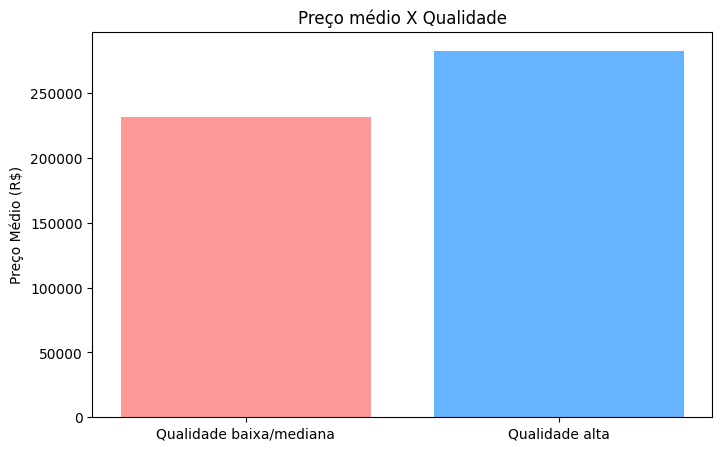

In [14]:
import matplotlib.pyplot as plt

medias = [grupo_b.mean(), grupo_a.mean()]
grupos = ['Qualidade baixa/mediana', 'Qualidade alta']

plt.figure(figsize=(8, 5))
plt.bar(grupos, medias, color=['#ff9999', '#66b3ff'])
plt.title('Preço médio X Qualidade')
plt.ylabel('Preço Médio (R$)')
plt.show()

O teste mostrou que:

* **Estatística t:** Existe uma divergência significativa entre as médias de preço dos grupos. Como é um número positivo, fica claro que o grupo de imóveis de alta qualidade têm preços superiores.

* **P-valor:** Como o valor é inferior ao nível de significância padrão (0.05), rejeitamos a H0.

Assim, a diferença observada não é por acaso e a variável de qualidade (OverallQual) é um preditor estatisticamente significante para o valor dos imóveis.

## Correlação de Pearson e Spearman
Analisando a relação entre as variáveis do dataset e o preço de venda (SalePrice).
* **Pearson:** Mede relações lineares.
* **Spearman:** É mais robusta contra outliers e relações não lineares.

In [3]:
# Calculando a correlação de Pearson e Spearman das variáveis com o SalePrice
correlacoes = pd.DataFrame({
	'Pearson': df.corr(method='pearson')['SalePrice'],
	'Spearman': df.corr(method='spearman')['SalePrice']
})

# Ordenando pelo valor de Pearson (mostra as mais fortes primeiro)
correlacoes['VPearson'] = correlacoes['Pearson'].abs()
correlacoes = correlacoes.sort_values(by='VPearson', ascending=False).drop(columns=['VPearson'])

display(correlacoes)

,Pearson,Spearman
SalePrice,1.000000,1.000000
GrLivArea,0.745095,0.747302
OverallQual,0.352899,0.336273
GarageCars,0.351321,0.343279
FullBath,0.273731,0.273307
TotalBsmtSF,0.250178,0.238178
YearBuilt,0.222142,0.214901
LotArea,-0.038982,-0.038448
Id,-0.025416,-0.024766
BedroomAbvGr,0.014113,0.005628


A partir dos coeficientes de Pearson e Spearman, fica claro que:
* Há uma correlação forte (aprx. 0.75) entre o preço e o tamanho de um imóvel. Assim, a área útil é o principal direcionador de preço, sendo mais relevante que as demais características.
* Enquanto isso, atributos como a qualidade geral e quantidade de vagas de garagem exercem uma influência moderada sobre o preço.
* Porém fatores como o tamanho do lote e o número de quartos apresentaram correlações próximas de zero, indicando pouca ou nenhuma relação.

Inicialmente, supus que a nota de qualidade seria o fator mias importante na precificação. Contudo, a matriz de correlação mostrou que o tamanho do imóvel exerce um impacto consideravelmente superior sobre o preço.

Assim, fica evidenciado que mesmo que um imóvel tenha uma qualidade nota 10, o tamanho continua importando mais.

In [15]:
# Calculando o p valor entre o tamanho e o preço
correlacao, pvalor = st.pearsonr(df['GrLivArea'], df['SalePrice'])

print(f"Correlação: {correlacao:.4f}")
print(f"P-valor: {pvalor}")

Correlação: 0.7451
P-valor: 2.358419974071214e-54


Para garantir a significância estatística da relação entre o tamanho e o preço, é preciso aplicar o teste de significância de Pearson.

O resultado mostrou um p valor de bem inferior ao limiar de significância de 5%, confirmando que o impacto do tamanho do imóvel sobre o preço não é por acaso.

## Modelo de Regressão Linear (OLS)
Construindo um modelo de Regressão Linear por OLS para quantificar o impacto do tamanho do imóvel sobre o preço de venda, gerando uma equação preditiva para os imóveis.

In [16]:
from sklearn.linear_model import LinearRegression

# Definindo a variável independente X (tamanho) e a dependente Y (preço)
X = df[['GrLivArea']]
Y = df['SalePrice']

regressao = LinearRegression()

# Treinando o modelo
regressao.fit(X, Y)

# Encontrando os coeficientes aprendidos
coeficiente_angular = regressao.coef_[0]
coeficiente_linear = regressao.intercept_

print(f"Intercepto: {coeficiente_linear:.2f}")
print(f"Coeficiente: {coeficiente_angular:.2f}")

Intercepto: 128588.40
Coeficiente: 53.60


Com base no modelo treinado utilizando o tamanho do imóvel como variável preditora do preço de venda, obtivemos os seguintes parâmetros para a equação da reta ($Y = \beta_0 + \beta_1X$):

* $\beta_0 = 128.588,40$
* $\beta_1 = 53,60$
  * Para cada unidade de aumento do tamanho, o valor de mercado do imóvel sofre um acréscimo médio de $53,60.

**Equação Preditiva:**
$$\text{Preço} = 128.588,40 + (53,60 \times \text{Tamanho})$$

Testando para um imóvel real do Dataset:

In [31]:
import warnings
warnings.filterwarnings('ignore')

# Pegando um imóvel aleatório
imovel = df.iloc[100]

tamanho = imovel['GrLivArea']
preco_real = imovel['SalePrice']

# Prevendo o preço desse mesmo imóvel
preco_previsto = regressao.predict([[tamanho]])[0]

print(f"Tamanho do imóvel: {tamanho}")
print(f"Preço real de venda no dataset: R$ {preco_real:,.2f}")
print(f"Preço previsto pelo modelo: R$ {preco_previsto:,.2f}")
print(f"Diferença: $ {abs(preco_real - preco_previsto):,.2f}")

Tamanho do imóvel: 3921
Preço real de venda no dataset: R$ 346,529.00
Preço previsto pelo modelo: R$ 338,751.58
Diferença: $ 7,777.42


Aplicando a equação a um imóvel aleatório para testar a capacidade preditiva do modelo na prática,, vemos que o modelo apresentou uma precisão muito boa.

O erro foi de uma margem muito pequena em relação ao valor de mercado real do imóvel. O que demonstra que a equação aprendida é eficiente para estimar o valor de propriedades que se alinham à tendência central da amostra.

In [29]:
# Calculando o R² (Coeficiente de Determinação)
r2 = regressao.score(X, Y)

print(f"R² do modelo: {r2:.4f}")

R² do modelo: 0.5552


## Avaliação e Interpretação

* **Coeficiente de Determinação ($R^2 = 0,5552$):** Este valor indica que aproximadamente 55,52% da variação nos preços dos imóveis é explicada unicamente pelo tamanho.
  * No cenário do mercado imobiliário, onde o preço é influenciado por dezenas de fatores, este é um resultado robusto, confirmando que o tamanho é o pilar central da precificação nesta base de dados.

* **Interpretação dos Coeficientes:**
  * Intercepto ($128.588,40$): Representa o preço base inicial, que o modelo atribui como valor de entrada.
  * Coeficiente Angular ($53,60$): Indica que, para cada unidade de área adicional (sqft), o valor de venda do imóvel aumenta, em média, em R$ 53,60.

* **Análise de Resíduos:**
  O gráfico de resíduos permite visualizar a distribuição do erro do modelo.
    * Como os pontos estão distribuídos de forma relativamente aleatória em torno da linha zero, isso indica que o modelo de regressão linear é uma escolha adequada e não apresenta tendências sistemáticas de erro.

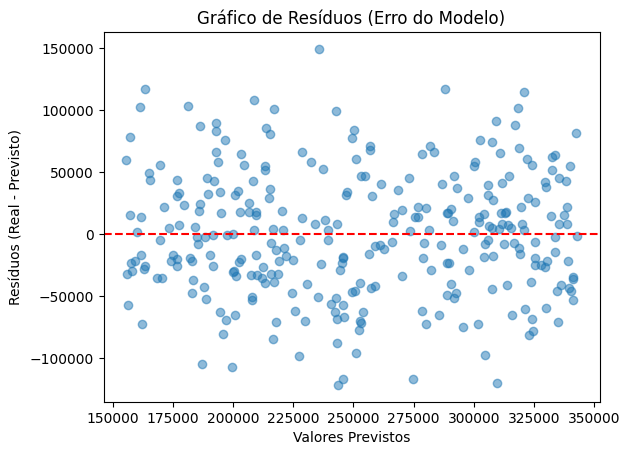

In [30]:
# Calculando as predições e os resíduos
Yprevisto = regressao.predict(X)
residuos = Y - Yprevisto

# Plota o gráfico de resíduos
plt.scatter(Yprevisto, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Resíduos (Erro do Modelo)')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos (Real - Previsto)')
plt.show()

## Conclusão do Projeto

Este projeto demonstrou, através de uma análise exploratória e da modelagem estatística, que existe uma relação direta e significativa entre a área útil de um imóvel e seu preço de venda.

Embora o tamanho seja um fator extremamente relevante, a métrica $R^2$ de 55,5% sugere que a precificação é um fenômeno mais complexo.

Futuramente, esse modelo pode ser expandido para uma Regressão Linear Múltipla, incorporando variáveis como OverallQual e YearBuilt para reduzir os resíduos e aumentar a precisão preditiva do modelo.